<a href="https://colab.research.google.com/github/ankxie/PHYS633/blob/main/Book/L10-Absorption/10-Absorption-template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="purple">Notebook 10-Absorption</font> (template)

We start by importing the modules
* Numpy -- operations on arrays and matrixes (and pi)
* Matplotlib pyplot -- plotting library
* Matplotlin patches -- module that enables patches in plots
* Astropy units -- defined quantities with units. We also import the CDS conversions

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
%matplotlib inline

from astropy import constants as const
import astropy.units as u
from astropy.units import cds
cds.enable()

## 0. To execute: Below is a little function that created a gradiant of color between two curves, according to a certain function.

In [2]:
def rect(ax,x,y,w,h,c):
    #ax = plt.gca()
    polygon = plt.Rectangle((x,y),w,h,color=c)
    ax.add_patch(polygon)

def rainbow_fill_between(ax, X, Y1, Y2, colors=None,
                         cmap=mpl.colormaps["Reds"],**kwargs):
    plt.plot(X,Y1,lw=0)  # Plot so the axes scale correctly

    dx = X[1]-X[0]
    N  = X.size

    #Pad a float or int to same size as x
    if (type(Y2) is float or type(Y2) is int):
        Y2 = np.array([Y2]*N)

    #No colors -- specify linear
    if colors is None:
        colors = []
        for n in range(N):
            colors.append(cmap(n/float(N)))
    #Varying only in x
    elif len(colors.shape) == 1:
        colors = cmap((colors-colors.min())
                      /(colors.max()-colors.min()))
    #Varying only in x and y
    else:
        cnp = np.array(colors)
        colors = np.empty([colors.shape[0],colors.shape[1],4])
        for i in range(colors.shape[0]):
            for j in range(colors.shape[1]):
                colors[i,j,:] = cmap((cnp[i,j]-cnp[:,:].min())
                                    /(cnp[:,:].max()-cnp[:,:].min()))

    colors = np.array(colors)

    #Create the patch objects
    for (color,x,y1,y2) in zip(colors,X,Y1,Y2):
        rect(ax,x,y2,dx,y1-y2,color,**kwargs)

## 1. In class: Imagine an ray of light entering a slab of constant density and opacity.

* The lenght of the slab ($d$) is 4 length units.
* The product of the opacity and the density give a fraction of $\kappa\rho$ = 0.25 per unit of length.

### a. Find and plot the intensity as the ray crosses the slab.

> **TODO** : Starting from the $dI_\lambda$ equation, derive the equation for $I(s)$ for a constant density and opacity. Show your work here. Add a curve of $I(s)$ to the plot in the code below.

$$dI_\lambda = -I_\lambda \rho\kappa_\lambda ds$$

We divide by $I_\lambda$ to group together like terms.

$$\frac{dI_\lambda}{I_\lambda} = -\rho(s)\kappa_\lambda(s) ds$$

We will integrate this expression. We take the start of the slab to be at $s_0$, with a known intensity of $I_{\lambda,0}$. We make that our lower bound of integration, and make our upper bound $I_{\lambda}$ at $s$, which we are solving for.

$$\int_{I_{\lambda,0}}^{I_{\lambda}(s)} \frac{dI_\lambda}{I_\lambda} = \int_{s_0}^{s} -\rho(s)\kappa_\lambda (s)ds$$

In this case, $\rho(s)\kappa_\lambda$ is a constant. So we can pull it out of the integral, and evaluate it.

$$ln(\frac{I_{\lambda}(s)}{I_{\lambda,0}}) = -\rho\kappa_\lambda(s - s_0)$$

$$I_{\lambda}(s) = I_{\lambda,0}e^{-\rho\kappa_\lambda(s - s_0)}$$

### b. Find and plot the optical depth everywhere in the slab.

> **TODO** : Integrate the equation for $d\tau$ to find $\tau(s)$. Show your work here. Add a curve of $\tau(s)$ to the plot in the code below.

$$d\tau_\lambda = -\kappa_\lambda(s)\rho(s)ds$$

We choose one of our bounds of integration to be at the observer because we know that $\tau = 0$ at the observer.

$$\int_{0}^{\tau_\lambda(s)} d\tau_\lambda= \int_{s_{observer}}^{s} -\kappa_\lambda(s)\rho(s) ds$$

$$\tau_\lambda(s) = \int_{s_{observer}}^{s} -\kappa_\lambda(s)\rho(s) ds$$

In this case, $\rho(s)\kappa_\lambda$ is a constant. So we can pull it out of the integral, and evaluate it.

$$\tau_\lambda(s) = -\kappa_\lambda\rho(s - s_{observer})$$

<br>
<br>
<font color="red">Don't forget to add axis labels and legends to your plots</font>

Text(0, 0.5, 'intensity, optical depth')

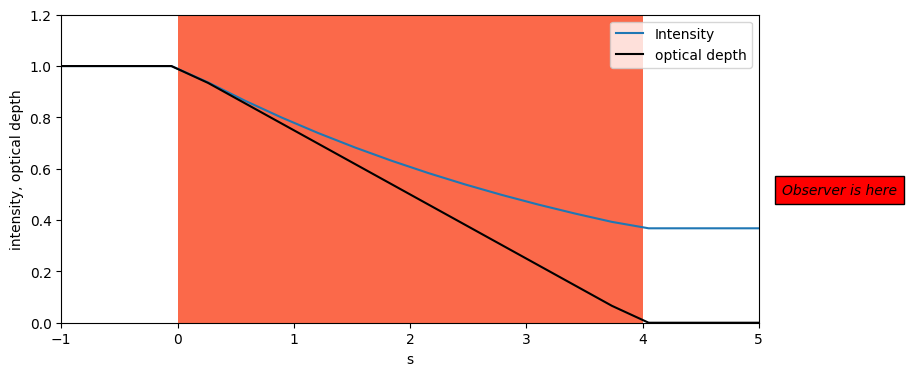

In [18]:
fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.set_ylim(0, 1.2)
ax.set_xlim(-1,5)

# For the first graph, I want a patch with constant color
cmap = mpl.colormaps["Reds"]
rgba = cmap(0.5) # pick the color in the center of the color map
rec = mpatches.Rectangle( (0, 0), 4 , 1.2, fc=rgba) # Create a shaded rectangle
r = ax.add_patch(rec) # add the rectangle to the plot
t = ax.text(5.2, 0.5, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})



#---------------------------------------
# a. Intensity

def I(s):
  I0 = 1
  I_array = []
  rhokappa = 0.25
  for i in range(len(s)):
    if s[i] > 0 and s[i] < 4:
      I_array = np.append(I_array, I0 * np.exp(-1* rhokappa * s[i]))

    if s[i] <= 0:
      I_array = np.append(I_array, 1)

    if s[i] >= 4:
      I_array = np.append(I_array, I0 * np.exp(-1*rhokappa * 4))

  return I_array

s_array = np.linspace(-1, 5, 20)
ax.plot(s_array, I(s_array), label = 'Intensity')

#---------------------------------------
# b. optical depth

def tau(s):
  rhokappa = 0.25
  tau_array = []
  for i in range(len(s)):
    if s[i] > 0 and s[i] <= 4:
      tau_array = np.append(tau_array, -rhokappa * (s[i] - 4))

    if s[i] > 4:
      tau_array = np.append(tau_array, 0)

    if s[i] <= 0:
      tau_array = np.append(tau_array, -rhokappa * (0 - 4))

  return tau_array

ax.plot(s_array, tau(s_array), c = 'k', label = 'optical depth')

#--------------------------
# For a legend, add label='text' to the ax.plot command
# for which you would like a legend entry, and uncomment
# the following line:
ax.legend(loc=0)

ax.set_xlabel('s')
ax.set_ylabel('intensity, optical depth')

> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

The intensity of a ray of light traveling through the slab decreases with the distance it travels. The optical depth also decreases further along the ray's path in the slab. A change of 1 $\tau$ corresponds with the intensity decreasing by a factor of e. The change of optical depth across a distance can tell us about the change in intesity across that distance.

## 2. At home: Imagine now that the density in the slab changes such that:

$\rho(s) = \rho_o \left( 1- \frac{s}{d} \right),$

where $d$ is the length of the slab.

> **TODO**:
>
> a. Find an expression for $I(s)$ if the density changed as above and if the opacity remains constant. Make your integral unit-less before integrating. Show your work here.

$$\int_{I_{\lambda,0}}^{I_{\lambda}(s)} \frac{dI_\lambda}{I_\lambda} = \int_{s_0}^{s} -\rho(s)\kappa_\lambda (s)ds$$

$$I_{\lambda}(s) = I_{\lambda,0}e^{-\int_{s_0}^{s} \rho(s)\kappa_\lambda ds}$$

$$I_{\lambda}(s) = I_{\lambda,0}e^{-\int_{s_0}^{s} \rho_o \left( 1- \frac{s}{d} \right)\kappa_\lambda ds}$$

$$u = \frac{s}{d}, du = \frac{ds}{d}$$

$$I_{\lambda}(s) = I_{\lambda,0}e^{- \rho_o \kappa_\lambda \int_{u_0}^{u}  d\left( 1- u \right) du}$$

$$I_{\lambda}(s) = I_{\lambda,0}e^{- \rho_o \kappa_\lambda d (u - u_0 - \frac{u^2}{2} + \frac{u_0^2}{2})}$$

>
> b. Analytically, find what the value of $\rho_o \kappa$ has to be for the final intensity to be the same as that of #1. Show your work here

$$I_f = I_{\lambda,0}e^{-4* 0.25}$$

$$-1 = - \rho_o \kappa_\lambda d (u_f - u_0 - \frac{u_f^2}{2} + \frac{u_0^2}{2})$$

Substitute values for a slab of length 4.

$$d = 4, u_0 = 0, u_f = 1$$

$$\rho_o \kappa_\lambda = 0.5$$

>
> c. In the graph below, plot the intensity as a function of position (with the value you found for $\rho_o \kappa$ in part b.).
>
> d. Find an expression for the optical depth everywhere in the slab. Make your integral unit-less before integrating. Show your work here.
>
> e. In the graph below, add a curve for $\tau(s)$.

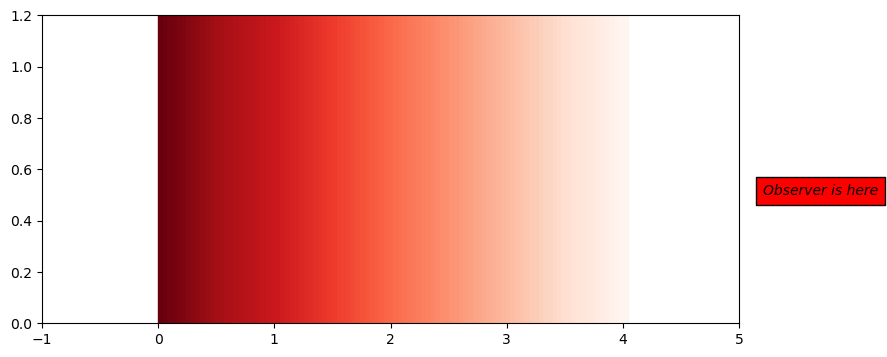

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(9,4))

ax.set_ylim(0, 1.2)
ax.set_xlim(-1,5)

# Create a patch with a gradient to illustrate
# the change in density
X=np.linspace(0,4,100)
Y1=np.copy(X)*0
Y2=np.copy(X)*0+4
g = 1.0-np.copy(X/4)
r = rainbow_fill_between(ax,X,Y1,Y2,colors=g)
t = ax.text(5.2, 0.5, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})

#---------------------------------------
#---------------------------------------
# At home

# Intensity

def u(s):
  d = 4
  return s/d

def I(s):
  I0 = 1
  I_array = []
  rhokappa = 0.5
  d = 4

  for i in range(len(s)):
    u = u(s[i])

    if s[i] > 0 and s[i] < 4:
      I_array = np.append(I_array, I0 * np.exp(-1* rhokappa * d * (u - 0.5)))

    if s[i] <= 0:
      I_array = np.append(I_array, 1)

    if s[i] >= 4:
      I_array = np.append(I_array, I0 * np.exp(-1*rhokappa * 4))

  return I_array

s_array = np.linspace(-1, 5, 20)
ax.plot(s_array, I(s_array))

#--------------------------
# For a legend, add label='text' to the ax.plot command
# for which you would like a legend entry, and uncomment
# the following line:
#ax.legend(loc=0)

> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

## 3. Reading assignement: "what can we measure about stars" -- part 4

In this graduate course, we are making an advanced physical and mathematical model of star.

But it is still good to learn and/or remind ourselves about which physical characteristics of stars we can actually measure. You might have covered some of this in some details in previous physics or astro courses (at UD PHYS 133, 144, 333, or 469) -- but it is still a good idea to have a quick look at the suggested reading below before crafting your paragraph.

One other thing that can be measured is the **mass** of a star.

> **TODO**: Have a look at section 18.2 Measuring Stellar Masses of the Open Stack Astronomy online [textbook](https://openstax.org/books/astronomy/pages/5-2-the-electromagnetic-spectrum), and write a short conceptual paragraph about how astronomer can determine the masses of stars.